# Dane dyskretne, PMF, PDF i całkowanie numeryczne

Ten notebook porządkuje różnicę między:
- **danymi dyskretnymi**,
- **PMF** (*probability mass function*),
- **PDF** (*probability density function*),
- **sumowaniem** i **całkowaniem**.

Celem jest zbudowanie intuicji oraz pokazanie prostych obliczeń numerycznych w Pythonie.

## 1. Dane dyskretne

Dane dyskretne przyjmują konkretne, oddzielne wartości, na przykład:
- liczba dzieci,
- liczba wizyt,
- ocena 2, 3, 4, 5.

Dla takich danych naturalnym obiektem jest **PMF** (*probability mass function*), czyli funkcja przypisująca każdej wartości prawdopodobieństwo:

$$
P(X = x_i)
$$

W przypadku danych dyskretnych:
- interesuje nas prawdopodobieństwo **dokładnie tej wartości**,
- prawdopodobieństwa dla wszystkich wartości sumują się do 1:

$$
\sum_i P(X = x_i) = 1
$$

In [1]:
import numpy as np
import pandas as pd

grades = np.array([2, 3, 3, 4, 4, 4, 5, 5])

pmf = pd.Series(grades).value_counts(normalize=True).sort_index()
pmf

2    0.125
3    0.250
4    0.375
5    0.250
dtype: float64

Wynik powyżej można interpretować jako przybliżenie PMF na podstawie częstości względnych w próbce.

In [2]:
print("Suma prawdopodobieństw:", pmf.sum())
print("P(X = 4) =", pmf.loc[4])

Suma prawdopodobieństw: 1.0
P(X = 4) = 0.375


## 2. Dane ciągłe i PDF

Dane ciągłe mogą przyjmować dowolne wartości z pewnego przedziału, na przykład:
- wzrost,
- masa,
- czas,
- temperatura.

Dla takich danych używamy **PDF** (*probability density function*), czyli funkcji gęstości prawdopodobieństwa:

$$
f(x)
$$

W przypadku rozkładu ciągłego:
- prawdopodobieństwo pojedynczego punktu jest równe 0,
- znaczenie ma dopiero prawdopodobieństwo przedziału:

$$
P(a \le X \le b) = \int_a^b f(x)\,dx
$$

Całkowite pole pod wykresem PDF wynosi 1:

$$
\int_{-\infty}^{\infty} f(x)\,dx = 1
$$

## 3. Kluczowa różnica: sumowanie vs całkowanie

Dla danych dyskretnych:

$$
\sum_i P(X = x_i) = 1
$$

Dla danych ciągłych:

$$
\int f(x)\,dx = 1
$$

Najkrócej:
- **PMF** mówi o prawdopodobieństwie konkretnej wartości,
- **PDF** mówi o gęstości rozkładu,
- dla dyskretnych **sumujemy**,
- dla ciągłych **całkujemy**.

## 4. Przykład PDF: rozkład normalny

Poniżej tworzymy teoretyczny PDF rozkładu normalnego:

$$
f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left(-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2\right)
$$

i numerycznie sprawdzamy, czy pole pod wykresem jest równe 1.

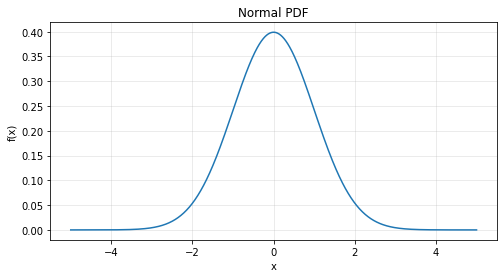

In [3]:
import matplotlib.pyplot as plt

mu = 0
sigma = 1

x = np.linspace(-5, 5, 1000)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

plt.figure(figsize=(8, 4))
plt.plot(x, pdf)
plt.title('Normal PDF')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(alpha=0.3)
plt.show()

In [6]:
area = np.trapz(pdf, x)
print("Przybliżone pole pod PDF:", area)

Przybliżone pole pod PDF: 0.9999994265727195


W praktyce nie liczymy tutaj dokładnej całki analitycznej, lecz używamy **całkowania numerycznego**.  
Wynik powinien być bardzo bliski 1.

## 5. Prawdopodobieństwo przedziału przez całkowanie numeryczne

Dla rozkładu ciągłego nie pytamy zwykle o:

$$
P(X = 1)
$$

bo to jest równe 0.

Zamiast tego pytamy o prawdopodobieństwo przedziału, na przykład:

$$
P(-1 \le X \le 1)
$$

czyli o pole pod krzywą PDF na tym przedziale.

P(-1 <= X <= 1) ≈ 0.680743868489627


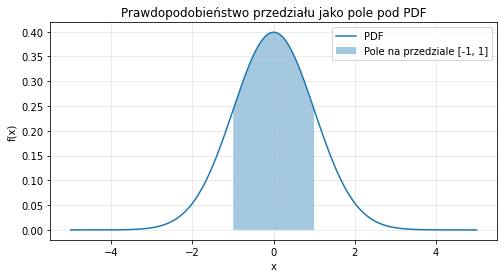

In [8]:
mask = (x >= -1) & (x <= 1)
prob_interval = np.trapz(pdf[mask], x[mask])

print("P(-1 <= X <= 1) ≈", prob_interval)

plt.figure(figsize=(8, 4))
plt.plot(x, pdf, label='PDF')
plt.fill_between(x[mask], pdf[mask], alpha=0.4, label='Pole na przedziale [-1, 1]')
plt.title('Prawdopodobieństwo przedziału jako pole pod PDF')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Histogram jako przybliżenie rozkładu

W praktyce zwykle nie znamy prawdziwego PDF.  
Mamy tylko próbkę danych.

Dlatego używamy:
- **histogramu**,
- albo **estymacji gęstości**,

aby przybliżyć rozkład zmiennej ciągłej.

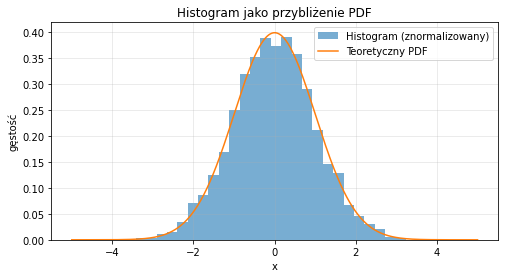

In [9]:
samples = np.random.normal(loc=0, scale=1, size=5000)

plt.figure(figsize=(8, 4))
plt.hist(samples, bins=30, density=True, alpha=0.6, label='Histogram (znormalizowany)')
plt.plot(x, pdf, label='Teoretyczny PDF')
plt.title('Histogram jako przybliżenie PDF')
plt.xlabel('x')
plt.ylabel('gęstość')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Gdy histogram jest znormalizowany (`density=True`), całkowite pole słupków jest równe 1.  
Dzięki temu można go interpretować jako przybliżenie gęstości.

## 7. Ważne rozróżnienie: dane zapisane dyskretnie vs zmienna ciągła

To, że dane w komputerze są zapisane jako skończona lista liczb, **nie oznacza jeszcze**, że sam model zmiennej musi być dyskretny.

Przykład:
- lista 5000 pomiarów wzrostu jest zapisana dyskretnie jako próbka,
- ale wzrost traktujemy jako zmienną ciągłą.

Wtedy:
- próbka jest skończona,
- ale opis statystyczny może używać PDF i całkowania.

## 8. Podsumowanie

- dane dyskretne opisujemy przez **PMF** i **sumowanie**,
- dane ciągłe opisujemy przez **PDF** i **całkowanie**,
- histogram jest dyskretnym przybliżeniem rozkładu,
- całkowanie numeryczne pozwala przybliżać pola pod wykresem,
- prawdopodobieństwo przedziału w rozkładzie ciągłym to pole pod PDF.

To rozróżnienie jest bardzo ważne przy interpretacji histogramów, KDE i wykresów gęstości.